In [2]:
import pandas as pd               # Data handling and manipulation
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Advanced visualization

In [3]:
# Loading multiple CSV files (data is split into parts)

df1 = pd.read_csv("jan to march.csv")
df2 = pd.read_csv("march to may.csv")
df3 = pd.read_csv("may to july.csv")
df4 = pd.read_csv("july to november.csv")

# Combine all datasets into one
df = pd.concat([df1, df2, df3, df4])

In [4]:
# Checking structure of dataset

print(df.shape)     # Number of rows and columns


(21960, 4)


In [5]:
# Checking structure of dataset
print(df.head())    # First few rows


     Eastern Date Hour Zone Name  Zone PTID  TWI Actual Load
0  2018/01/01 00:00:00    CAPITL      61757           1609.3
1  2018/01/01 00:00:00    LONGIL      61762           2596.1
2  2018/01/01 00:00:00    N.Y.C.      61761           6073.3
3  2018/01/01 01:00:00    CAPITL      61757           1562.3
4  2018/01/01 01:00:00    LONGIL      61762           2482.9


In [6]:
print(df.info())    # Data types and missing values

<class 'pandas.DataFrame'>
Index: 21960 entries, 0 to 6554
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Eastern Date Hour  21960 non-null  str    
 1   Zone Name          21960 non-null  str    
 2   Zone PTID          21960 non-null  int64  
 3   TWI Actual Load    21960 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 857.8 KB
None


In [7]:
# Converting dataset from long format to wide format
# Each zone becomes a separate column

df_pivot = df.pivot_table(
    index='Eastern Date Hour',
    columns='Zone Name',
    values='TWI Actual Load'
)

df_pivot = df_pivot.reset_index()

# Rename datetime column for clarity
df_pivot.rename(columns={'Eastern Date Hour': 'datetime'}, inplace=True)

# Convert to datetime format
df_pivot['datetime'] = pd.to_datetime(df_pivot['datetime'])

In [8]:
# Checking missing values
print(df_pivot.isnull().sum())

Zone Name
datetime    0
CAPITL      0
LONGIL      0
N.Y.C.      0
dtype: int64


In [9]:
# Checking duplicate rows
print(df_pivot.duplicated().sum())

0


In [10]:
# Checking if any zero values exist
print((df_pivot == 0).sum())

Zone Name
datetime    0
CAPITL      0
LONGIL      0
N.Y.C.      0
dtype: int64


In [11]:
df_pivot[['CAPITL','LONGIL','N.Y.C.']] = df_pivot[['CAPITL','LONGIL','N.Y.C.']].replace(0, np.nan)

In [12]:
# Filling missing values using mean 

df_pivot['CAPITL'] = df_pivot['CAPITL'].fillna(df_pivot['CAPITL'].mean())
df_pivot['LONGIL'] = df_pivot['LONGIL'].fillna(df_pivot['LONGIL'].mean())
df_pivot['N.Y.C.'] = df_pivot['N.Y.C.'].fillna(df_pivot['N.Y.C.'].mean())

In [13]:
print("Before filling:")
print(df_pivot[['CAPITL','LONGIL','N.Y.C.']].isnull().sum())

# Fill again (just for demo)
df_pivot[['CAPITL','LONGIL','N.Y.C.']] = df_pivot[['CAPITL','LONGIL','N.Y.C.']].fillna(df_pivot.mean())

print("After filling:")
print(df_pivot[['CAPITL','LONGIL','N.Y.C.']].isnull().sum())

Before filling:
Zone Name
CAPITL    0
LONGIL    0
N.Y.C.    0
dtype: int64
After filling:
Zone Name
CAPITL    0
LONGIL    0
N.Y.C.    0
dtype: int64


In [14]:
# Although no missing values were found, 
# imputation techniques were applied as a precautionary step.

In [15]:
# Extracting useful time-based features

df_pivot['hour'] = df_pivot['datetime'].dt.hour
df_pivot['month'] = df_pivot['datetime'].dt.month
df_pivot['dayofweek'] = df_pivot['datetime'].dt.dayofweek

In [23]:
# Creating total electricity demand across zones

df_pivot['total_load'] = df_pivot[['N.Y.C.', 'LONGIL', 'CAPITL']].sum(axis=1)

In [21]:
# Loading temperature dataset
temp = pd.read_csv("best temp data.csv")

# Display first rows
temp.head()

,STATION,NAME,DATE,TMAX,TMIN
0,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2018-01-01,18,7
1,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2018-01-02,26,13
2,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2018-01-03,28,12
3,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2018-01-04,29,19
4,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2018-01-05,19,9


In [24]:
temp['DATE'] = pd.to_datetime(temp['DATE'])                #converting DATE into date

In [25]:
temp['temperature'] = (temp['TMAX'] + temp['TMIN']) / 2    #Checking the temp column

In [26]:
temp = temp[['DATE', 'temperature']]
temp.rename(columns={'DATE': 'date'}, inplace=True)

In [27]:
df_pivot['date'] = df_pivot['datetime'].dt.date
temp['date'] = pd.to_datetime(temp['date']).dt.date

In [28]:
df_final = pd.merge(df_pivot, temp, on='date', how='left')      #Merging the two datasets

In [29]:
df_final[['datetime', 'date', 'temperature']].head()

,datetime,date,temperature
0,2018-01-01 00:00:00,2018-01-01,12.5
1,2018-01-01 01:00:00,2018-01-01,12.5
2,2018-01-01 02:00:00,2018-01-01,12.5
3,2018-01-01 03:00:00,2018-01-01,12.5
4,2018-01-01 04:00:00,2018-01-01,12.5


In [30]:
# Check missing values
print(temp.isnull().sum())

date           0
temperature    0
dtype: int64


In [31]:
print(temp.duplicated().sum())

# Remove duplicates
temp = temp.drop_duplicates()

0


In [33]:
temp = temp.sort_values(by='date')
print(temp)

           date  temperature
0    2018-01-01         12.5
1    2018-01-02         19.5
2    2018-01-03         20.0
3    2018-01-04         24.0
4    2018-01-05         14.0
..          ...          ...
360  2018-12-27         40.5
361  2018-12-28         49.0
362  2018-12-29         46.5
363  2018-12-30         35.5
364  2018-12-31         39.5

[365 rows x 2 columns]


In [34]:
#GRAPHS FOR VISUALZITION :


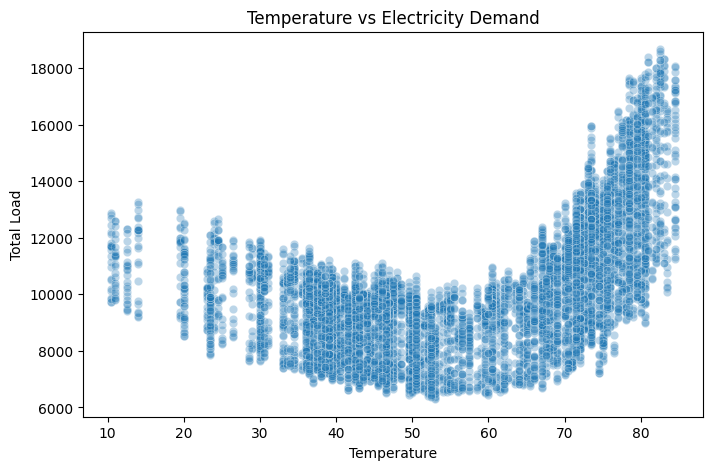

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temperature', y='total_load', data=df_final, alpha=0.3)

plt.title("Temperature vs Electricity Demand")
plt.xlabel("Temperature")
plt.ylabel("Total Load")

# This graph shows how temperature and electricity demand are related.
# Each point represents a data record.
# If points go upward → higher temperature increases load.
# If points go downward → colder temperature increases load.

plt.show()

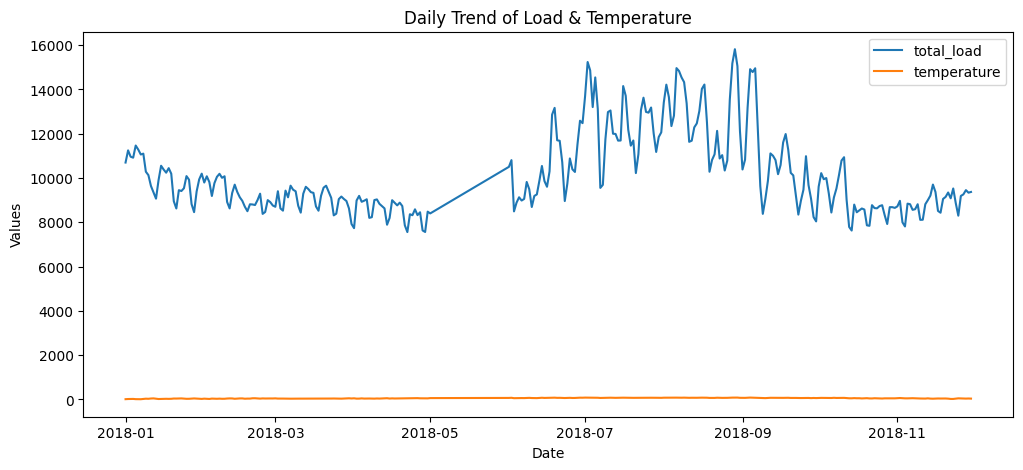

In [37]:
daily = df_final.groupby('date')[['total_load','temperature']].mean()

daily.plot(figsize=(12,5))

plt.title("Daily Trend of Load & Temperature")
plt.xlabel("Date")
plt.ylabel("Values")

# This graph shows how temperature and load change day by day.
# If both lines move together → strong relationship.
# If opposite → inverse relationship.
# Helps understand trends over time.

plt.show()

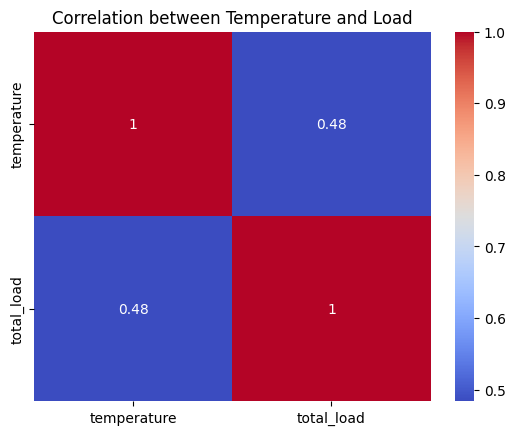

In [38]:
sns.heatmap(df_final[['temperature','total_load']].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation between Temperature and Load")

# This graph shows the correlation value between temperature and load.
# Value close to 1 → strong positive relationship.
# Value close to -1 → strong negative relationship.
# Value near 0 → weak or no relationship.

plt.show()

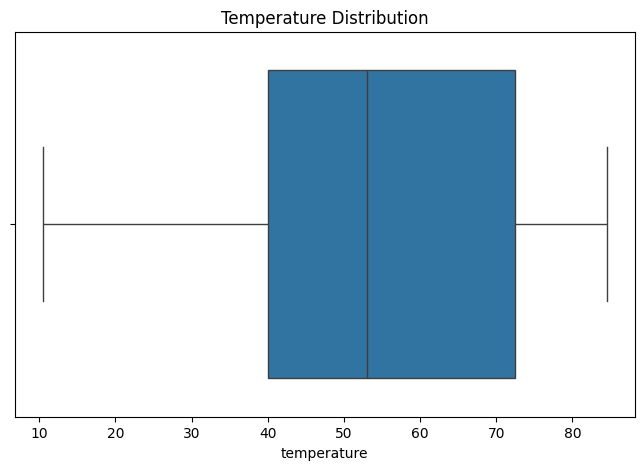

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['temperature'])

plt.title("Temperature Distribution")

# This graph shows the distribution of temperature.
# The box shows normal range.
# Points outside the box are outliers (extreme values).
# Helps detect unusual temperature values.

plt.show()

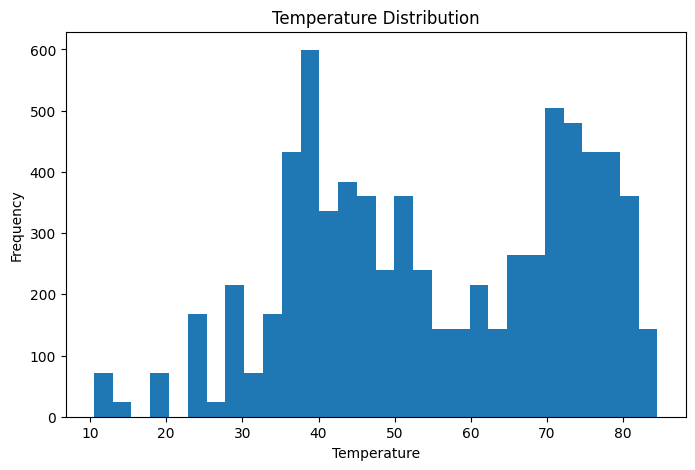

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df_final['temperature'], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

# This graph shows how often different temperature values occur.
# Taller bars → more frequent temperature range.
# Helps understand most common temperature values.

plt.show()

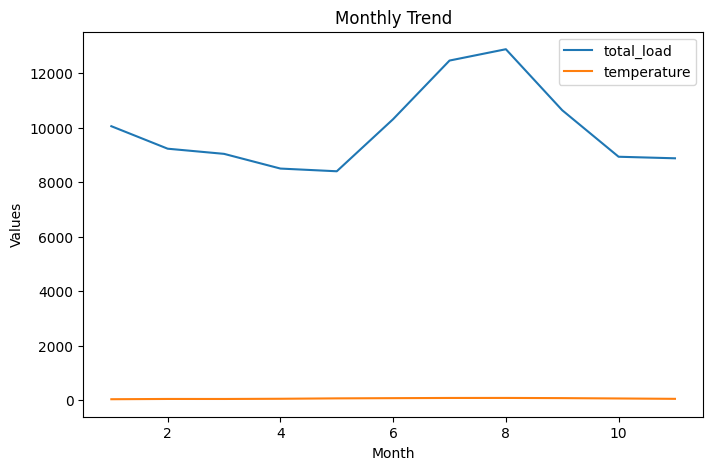

In [41]:
monthly = df_final.groupby('month')[['total_load','temperature']].mean()

monthly.plot(figsize=(8,5))

plt.title("Monthly Trend")
plt.xlabel("Month")
plt.ylabel("Values")

# This graph shows how load and temperature change month by month.
# Helps identify seasonal patterns.
# Example: higher load in summer or winter.

plt.show()

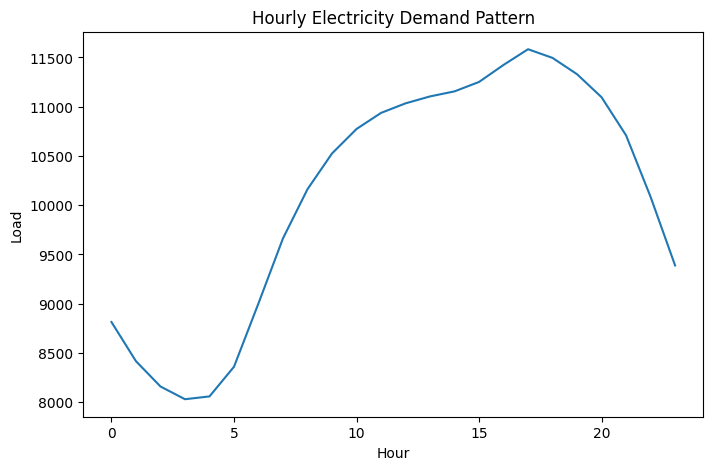

In [42]:
hourly = df_final.groupby('hour')['total_load'].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly.index, hourly.values)

plt.xlabel("Hour")
plt.ylabel("Load")
plt.title("Hourly Electricity Demand Pattern")

# This graph shows electricity usage at different hours of the day.
# Helps identify peak hours (usually evening).
# Useful for demand planning.

plt.show()

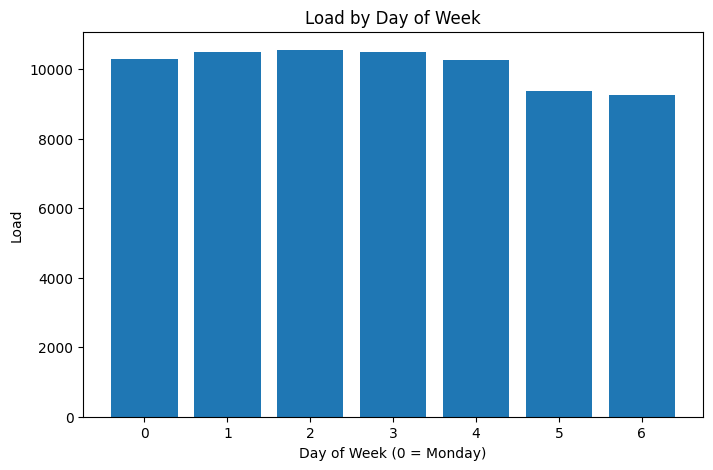

In [43]:
day = df_final.groupby('dayofweek')['total_load'].mean()

plt.figure(figsize=(8,5))
plt.bar(day.index, day.values)

plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Load")
plt.title("Load by Day of Week")

# This graph shows load variation across days of the week.
# Helps compare weekdays vs weekends.
# Can show higher usage on working days.

plt.show()

In [44]:
#MODEL TRAINING:


In [55]:
# Features (inputs)(independent variables)
# These are the factors that affect electricity demand
X = df_final[['temperature', 'hour', 'month', 'dayofweek']]

# Selecting target variable (dependent variable)
# This is what we want to predict
# Target (output)
y = df_final['total_load']

In [56]:
from sklearn.model_selection import train_test_split

# Splitting data into training and testing sets
# 80% data is used for training, 20% for testin
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# random_state ensures same split every time (reproducibility)

In [57]:
from sklearn.linear_model import LinearRegression

# Creating Linear Regression model
model = LinearRegression()

# Training the model using training data
model.fit(X_train, y_train)

# The model learns relationship between input features and output

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
# Making predictions on test data
y_pred = model.predict(X_test)

# These are the predicted electricity load values

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE: average error between actual and predicted values
mae = mean_absolute_error(y_test, y_pred)

# RMSE: penalizes large errors more strongly
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score: measures how well model explains the data (0 to 1)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1324.1540638875013
RMSE: 1688.5188694060232
R2 Score: 0.41148182631909613


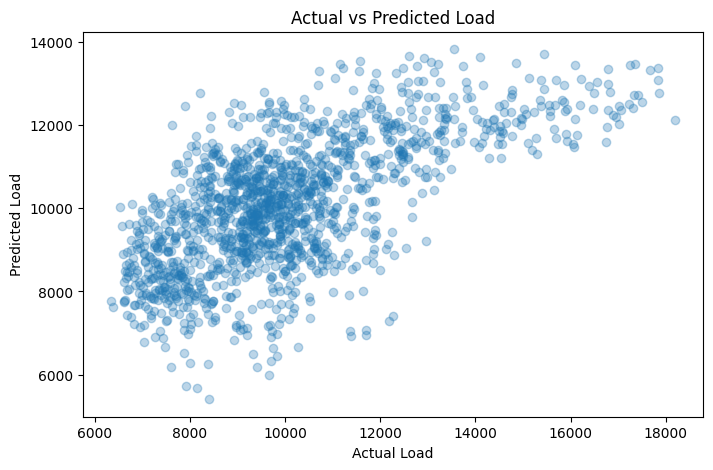

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Load")
plt.ylabel("Predicted Load")
plt.title("Actual vs Predicted Load")

# If points lie close to a diagonal line → model is accurate
# If points are scattered → model performance is weaker

plt.show()

In [61]:
# Example input:
# temperature = 25°C
# hour = 18 (6 PM)
# month = 6 (June)
# dayofweek = 2 (Wednesday)

sample = [[25, 18, 6, 2]]

# Predicting electricity load for given input
predicted_load = model.predict(sample)

print("Predicted Load:", predicted_load[0])

# This shows how model can be used for real-world prediction

Predicted Load: 8851.410186635865


C:\Users\Anshul Sharma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
